In [ ]:
# Authenticate with your GCP account
from google.colab import auth
auth.authenticate_user()

!pip install -q gcsfs

import pandas as pd
df = pd.read_parquet("gs://ba865-t9-mimiciv/parquet/cohort_model_input")

print("Shape:", df.shape)
print(df["readmitted_30d"].value_counts())
df.head(3)

Shape: (272842, 13)
readmitted_30d
0    211694
1     61148
Name: count, dtype: int64


,hadm_id,readmitted_30d,anchor_age,gender,los_days,prior_admissions,icd10_chapter,admission_type,insurance,creatinine,hemoglobin,heart_rate_discharge,discharge_text
0,20000502,1,49,M,4.71,0,8,EW EMER.,Private,0.8,12.8,82.0,\nName: ___ Unit No: ___\...
1,20002493,0,70,F,11.90,0,C,OBSERVATION ADMIT,Medicare,0.8,7.9,82.0,\nName: ___ Unit No: ___...
2,20003332,0,57,M,5.92,0,E,OBSERVATION ADMIT,Private,0.6,14.0,82.0,\nName: ___ Unit No: ___\n...


In [ ]:
!pip install -q keras_hub keras tensorflow

In [ ]:
import numpy as np
import tensorflow as tf
import keras
import keras_hub
from keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# Encode categoricals
for col in ["gender", "icd10_chapter", "admission_type", "insurance"]:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

structured_cols = [
    "anchor_age", "gender", "los_days", "prior_admissions",
    "icd10_chapter", "creatinine", "hemoglobin", "heart_rate_discharge",
    "admission_type", "insurance"
]

scaler   = StandardScaler()
X_struct = scaler.fit_transform(df[structured_cols].fillna(0))
y        = df["readmitted_30d"].values
texts    = df["discharge_text"].fillna("").tolist()

# Split — keep patient-level to avoid leakage
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y
)

X_struct_train, X_struct_test = X_struct[train_idx], X_struct[test_idx]
texts_train = [texts[i] for i in train_idx]
texts_test  = [texts[i] for i in test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(y_train)} | Test: {len(y_test)}")
print(f"Readmission rate (train): {y_train.mean():.3f}")

Train: 218273 | Test: 54569
Readmission rate (train): 0.224


In [ ]:
# Same as class 8.4 — load from keras_hub
tokenizer = keras_hub.models.Tokenizer.from_preset("roberta_base_en")
backbone  = keras_hub.models.Backbone.from_preset("roberta_base_en")

# Freeze backbone — use as feature extractor, not fine-tuning
backbone.trainable = False

backbone.summary()

Model: "roberta_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings          │ (None, None, 768) │ 38,996,736 │ token_ids[0][0]   │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_layer_n… │ (None, None, 768) │      1,536 │ embeddings[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embeddings_dropout  │ (None, None, 768) │          0 │ embeddings_layer… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_0 │ (None, None, 768) │  7,087,872 │ embeddings_dropo… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_1 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_2 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_3 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_4 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_5 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_6 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_7 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_8 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_9 │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_… │ (None, None, 768) │  7,087,872 │ transformer_laye… │
│ (TransformerEncode… │                   │            │ padding_mask[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_… │ (None, None, 768) │  7,087,872 │ transformer_laye

 Total params: 124,052,736 (473.22 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 124,052,736 (473.22 MB)

In [ ]:
BATCH_SIZE = 16

def preprocess_text(text, label):
    # Same StartEndPacker pattern as class 8.4
    packer = keras_hub.layers.StartEndPacker(
        sequence_length=512,
        start_value=tokenizer.start_token_id,
        end_value=tokenizer.end_token_id,
        pad_value=tokenizer.pad_token_id,
        return_padding_mask=True,
    )
    token_ids, padding_mask = packer(tokenizer(text))
    return {"token_ids": token_ids, "padding_mask": padding_mask}, label

train_text_ds = tf.data.Dataset.from_tensor_slices((texts_train, y_train)) \
    .map(preprocess_text).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_text_ds = tf.data.Dataset.from_tensor_slices((texts_test, y_test)) \
    .map(preprocess_text).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(next(iter(train_text_ds)))

({'token_ids': <tf.Tensor: shape=(16, 512), dtype=int32, numpy=
array([[    0,  1437, 50118, ..., 29360,     5,     2],
       [    0,  1437, 50118, ...,    12,  2983,     2],
       [    0,  1437, 50118, ..., 50118,   500,     2],
       ...,
       [    0,  1437, 50118, ...,  1437, 50118,     2],
       [    0,  1437, 50118, ...,   132,  5471,     2],
       [    0,  1437, 50118, ...,  1668,  6443,     2]], dtype=int32)>, 'padding_mask': <tf.Tensor: shape=(16, 512), dtype=bool, numpy=
array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])>}, <tf.Tensor: shape=(16,), dtype=int32, numpy=array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0], dtype=int32)>)


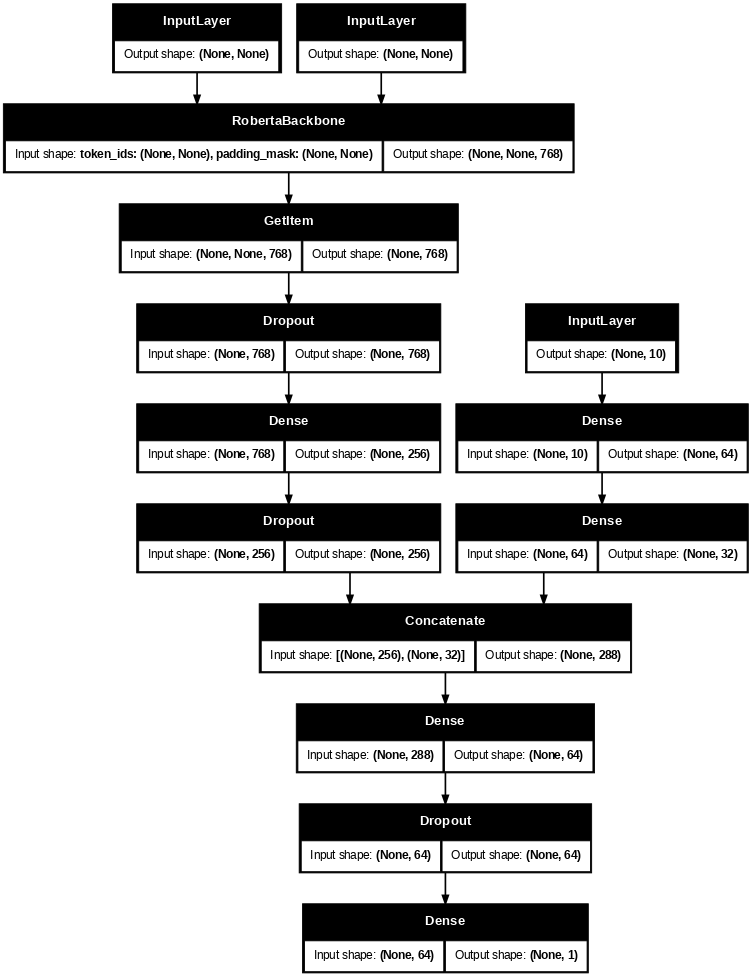

In [ ]:
# ── Text branch (class 8.4) ───────────────────────────────────────
text_inputs = backbone.input           # dict: {"token_ids": ..., "padding_mask": ...}
x_text = backbone(text_inputs)
x_text = x_text[:, 0, :]              # CLS token = document-level embedding
x_text = layers.Dropout(0.1)(x_text)
x_text = layers.Dense(256, activation="relu")(x_text)
x_text = layers.Dropout(0.1)(x_text)

# ── Structured branch (class 6.2) ─────────────────────────────────
struct_input = layers.Input(shape=(X_struct.shape[1],), name="structured")
x_struct = layers.Dense(64, activation="relu")(struct_input)
x_struct = layers.Dense(32, activation="relu")(x_struct)

# ── Merge with Concatenate (exactly as class 6.2) ─────────────────
merged = layers.Concatenate()([x_text, x_struct])
x = layers.Dense(64, activation="relu")(merged)
x = layers.Dropout(0.2)(x)
output = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(
    inputs={**text_inputs, "structured": struct_input},  # ← fix: merge dicts
    outputs=output
)

model.compile(
    optimizer=keras.optimizers.Adam(5e-5),
    loss="binary_crossentropy",
    metrics=["AUC", "accuracy"]
)

keras.utils.plot_model(model, show_shapes=True, dpi=60)

In [ ]:
train_struct_ds = tf.data.Dataset.from_tensor_slices(
    (X_struct_train.astype("float32"), y_train)
).batch(BATCH_SIZE)

test_struct_ds = tf.data.Dataset.from_tensor_slices(
    (X_struct_test.astype("float32"), y_test)
).batch(BATCH_SIZE)

def combine(text_batch, struct_batch):
    (text_inputs, labels), (struct_inputs, _) = text_batch, struct_batch
    return {**text_inputs, "structured": struct_inputs}, labels

train_ds = tf.data.Dataset.zip((train_text_ds, train_struct_ds)).map(combine)
test_ds  = tf.data.Dataset.zip((test_text_ds,  test_struct_ds)).map(combine)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    class_weight={0: 1, 1: 3}  # readmissions ~15-20% — handle class imbalance
)

Epoch 1/5
13643/13643 ━━━━━━━━━━━━━━━━━━━━ 4913s 360ms/step - AUC: 0.6418 - accuracy: 0.6857 - loss: 0.9540 - val_AUC: 0.6733 - val_accuracy: 0.6922 - val_loss: 0.6133
Epoch 2/5
13643/13643 ━━━━━━━━━━━━━━━━━━━━ 4004s 293ms/step - AUC: 0.6652 - accuracy: 0.6875 - loss: 0.9372 - val_AUC: 0.6790 - val_accuracy: 0.7028 - val_loss: 0.6014
Epoch 3/5
13643/13643 ━━━━━━━━━━━━━━━━━━━━ 3811s 279ms/step - AUC: 0.6714 - accuracy: 0.6865 - loss: 0.9321 - val_AUC: 0.6829 - val_accuracy: 0.6950 - val_loss: 0.5994
Epoch 4/5
13643/13643 ━━━━━━━━━━━━━━━━━━━━ 3838s 281ms/step - AUC: 0.6748 - accuracy: 0.6876 - loss: 0.9292 - val_AUC: 0.6856 - val_accuracy: 0.6816 - val_loss: 0.6091
Epoch 5/5
13643/13643 ━━━━━━━━━━━━━━━━━━━━ 3803s 279ms/step - AUC: 0.6771 - accuracy: 0.6882 - loss: 0.9268 - val_AUC: 0.6865 - val_accuracy: 0.6893 - val_loss: 0.6067


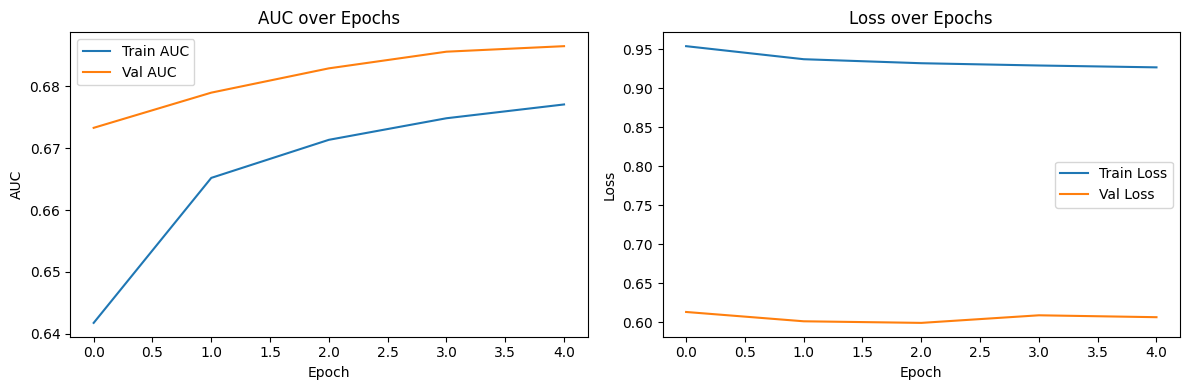

 871/3411 ━━━━━━━━━━━━━━━━━━━━ 9:27 223ms/step

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history["AUC"],     label="Train AUC")
ax1.plot(history.history["val_AUC"], label="Val AUC")
ax1.set_title("AUC over Epochs")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("AUC")
ax1.legend()

ax2.plot(history.history["loss"],     label="Train Loss")
ax2.plot(history.history["val_loss"], label="Val Loss")
ax2.set_title("Loss over Epochs")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

# Confusion matrix
y_pred     = model.predict(test_ds).flatten()
y_pred_bin = (y_pred > 0.5).astype(int)

print(f"Test AUC : {roc_auc_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred_bin)
ConfusionMatrixDisplay(cm, display_labels=["Not Readmitted", "Readmitted"]).plot()
plt.title("Confusion Matrix")
plt.show()